In [1]:
import modules.utils as u
u.Devices()._cuda_list_gpus()

[('cuda:1', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:2', 'NVIDIA A100-SXM4-80GB', 81041),
 ('cuda:3', 'NVIDIA A100-SXM4-80GB', 81041),
 ('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041),
 ('cuda:5', 'NVIDIA A100-SXM4-80GB', 74623),
 ('cuda:0', 'NVIDIA A100-SXM4-80GB', 63485)]

In [2]:
#### mv packages ####
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device(drop=['cuda:1','cuda:6'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

data = d.Preprocessor(brca, kegg, kegg)
_dataset = d.GraphDataset(data)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:4

# #### KEGG() ####
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:4)
# edge_attr                (32464, 16)              Tensor (cuda:4)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:4)

# #### TCGA() ####
# counts_path              PosixPath
# metadata_path            PosixPath
# gene_name_path           PosixPath
# metadata_complete        (1231, 93)               DataFrame
# metadata                 (1172, 2)                DataFrame
# y                        (1172,)                  Tensor (cuda:4)
# y_labels                 5                        list
# ensgv                    (60660, 3)               DataFrame
# ensg_complete            19213                    list
# cou

In [3]:
import modules.model as m
import modules.layers as l
import modules.train as t
import torch.nn as nn

loader = t.Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

dm = t.DataloaderMean(loader.train_loader, data.num_nodes, data.num_node_features)

x_mean = dm.get_mean(4)

classifier = m.Classifier(
    # dims
    data=data,
    head_dim=32,
    num_heads=10,
    
    # nb
    nb=True,
    x_mean=x_mean,

    # layers
    encoder_class=nn.Linear,
    pooling_class=l.SetPooling,
    mlp=True,
    method='set',

    # layer params
    hidden_dims=[128,128], 
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,
)

trainer = t.NBClassTrainer(
    model=classifier,
    loss_fn=nn.CrossEntropyLoss(data.class_weights),
    optimizer_kwargs={'lr':5e-4},
    # verbose=True,
    # report_metrics=['loss', 'micro_acc', 'macro_acc'],
)

---

In [4]:
from datetime import datetime
from tqdm import tqdm
import pandas as pd
from scipy import stats
import torch

from modules.data import GraphDataset
from modules.train import Loader, Trainer
from torch import Generator
from typing import Literal

In [5]:
class Experiment():
    def __init__(
        self,
        num_trials:int,
        num_epochs:int,
        dataset:GraphDataset,
        generator:Generator,
        batch_size:int=16,
        val_size:int=0.15,
        test_size:int=0.15,
    ):
        self.num_trials = num_trials
        self.num_epochs = num_epochs
        self.dataset = dataset
        self.generator = generator
        self.batch_size = batch_size
        self.val_size = val_size
        self.test_size = test_size

        # init configs
        self.configs = {}

    def add_trainer(self, config_name:str, trainer:Trainer):
        self.configs[config_name] = trainer

    def run_experiment(self, comment:str=None, verbose:bool=True, get_values:bool=False, save_csv:bool=False, save_model:bool=False):
        # make folder
        if True in [save_csv, save_model]:
            self.folder = self._get_folder(comment)
        else:
            self.folder = None

        # if verbose, use tqdm
        if verbose == True:
            pbar_trials = tqdm(range(self.num_trials))
        else:
            pbar_trials = range(self.num_trials)

        # init trackers
        dev_metrics = {}
        test_metrics = {}
        self.test_values = {} if get_values else None

        # trial loop
        for trial in pbar_trials:

            # init loader per trial
            trial_loader = Loader(
                dataset=self.dataset,
                generator=self.generator,
                batch_size=self.batch_size,
                val_size=self.val_size,
                test_size=self.test_size,
            )

            # add trial to trackers
            dev_metrics[trial] = {}
            test_metrics[trial] = {}
            if get_values:
                self.test_values[trial] = {}

            # for each config
            for config_name, config in self.configs.items():

                # run config with trial loader
                config.run(loader=trial_loader, num_epochs=self.num_epochs)

                # add trial config to trackers
                dev_metrics[trial][config_name] = config.dev_metrics
                test_metrics[trial][config_name] = config.test_metrics
                if get_values:
                    self.test_values[trial][config_name] = config.test_values

                # save model
                if save_model:
                    # make config subfolder
                    subfolder = self.folder / f'{config_name}'
                    subfolder.mkdir(parents=True, exist_ok=True)

                    # save model
                    state_dict = config.model.state_dict()
                    torch.save(state_dict, subfolder / f'{config_name}_trial_{trial}.pth')

        # convert to df
        self.dev_df = self._format_outputs(dev_metrics, 'dev', save_csv)
        self.test_df = self._format_outputs(test_metrics, 'test', save_csv)
        if get_values:
            self.test_values = self._format_outputs(self.test_values, 'values')

        # get summary
        self.summary = self._get_summary(self.test_df, save_csv)

    def _get_folder(self, comment:str=None):
        # get date, time
        date = datetime.now().strftime("%Y-%m-%d")
        time = datetime.now().strftime("%Hh%Mm%Ss").lower()

        # get dir name
        dir_name = f'{date}_{time}'

        if (comment != None) & (type(comment) == str): 
            dir_name = dir_name + f'_{comment}' # append comment if applicable

        # create folder
        folder = Path(f'./output/{dir_name}')
        folder.mkdir(parents=True, exist_ok=True)

        return folder
    
    def _format_outputs(self, x:dict, method:Literal['dev','test','values'], save_csv:bool=False):
        if method in ['dev', 'test']:
            # reshape rows
            if method == 'dev':
                rows = [
                    {
                        'trial': trial,
                        'config': config,
                        'epoch': epoch,
                        'stage': stage,
                        'metric': metric,
                        'value': value 
                    }
                    for trial, configs in x.items()
                    for config, epochs in configs.items()
                    for epoch, stages in epochs.items()
                    for stage, metrics in stages.items()
                    for metric, value in metrics.items()
                ]

            elif method == 'test':
                rows = [
                    {
                        'trial': trial,
                        'config': config,
                        'metric': metric,
                        'value': value
                    }
                    for trial, configs in x.items()
                    for config, metrics in configs.items()
                    for metric, value in metrics.items()
                ]

            # convert to df, write to csv
            df = pd.DataFrame(rows)

            # save csv
            if save_csv:
                df.to_csv(self.folder / f'{method}.csv', index=False)

            return df
        
        elif method == 'values':
            out = {}

            for trial, configs in x.items():
                for config_name, _variables in configs.items():
                    for _variable, value in _variables.items():
                        # initialize config dict if not already made
                        if _variable not in out:
                            out[_variable] = {}

                        # initialize var list if not already made
                        if config_name not in out[_variable]:
                            out[_variable][config_name] = []

                        # append value to list
                        out[_variable][config_name].append(value)
            
            return out

    def _get_summary(self, df:pd.DataFrame, save_csv:bool=False):
        # ci helper fxn
        def _get_ci(series:pd.Series, confidence:float=0.95):
            n = series.count()
            sem = stats.sem(series, nan_policy='omit')
            ci = sem * stats.t.ppf((1 + confidence) / 2., n - 1)
            return ci

        # group df, get summary stats
        summary_df = df.groupby(['config','metric'])['value'].agg(mean='mean', std='std', ci=_get_ci).reset_index()

        # save csv
        if save_csv:
            df.to_csv(self.folder / f'summary.csv', index=False)

        return summary_df


##


In [6]:
expt = Experiment(
    num_trials=10,
    num_epochs=20,
    dataset=_dataset,
    generator=generator,
    batch_size=128,
)

expt.add_trainer('config1', trainer)
expt.add_trainer('config2', trainer)
expt.run_experiment(comment='test_run')

100%|██████████| 10/10 [02:57<00:00, 17.77s/it]


---

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

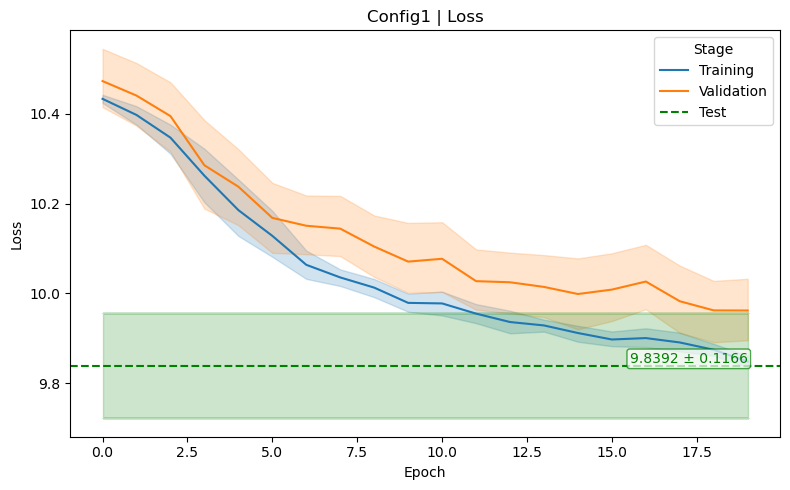

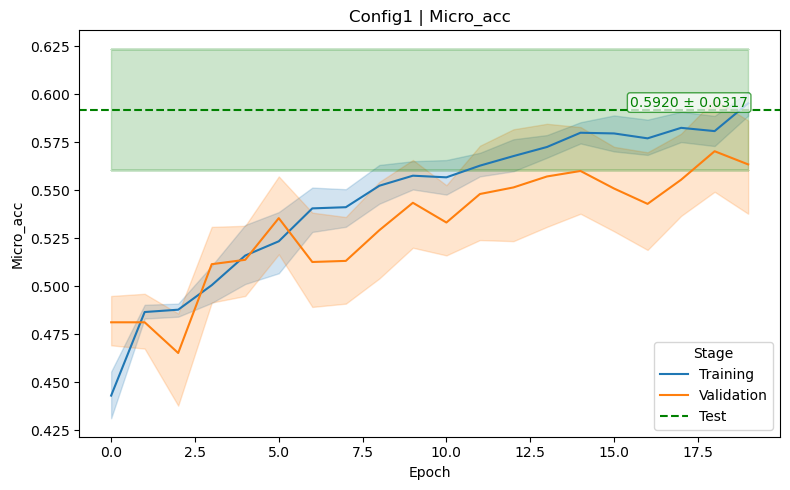

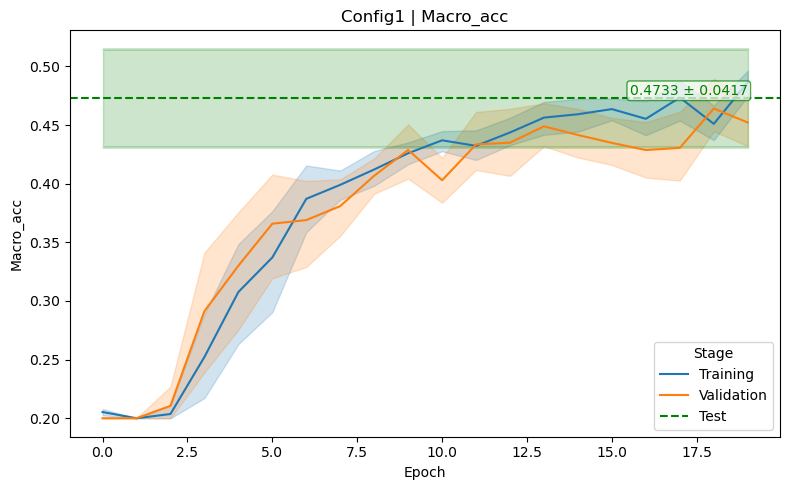

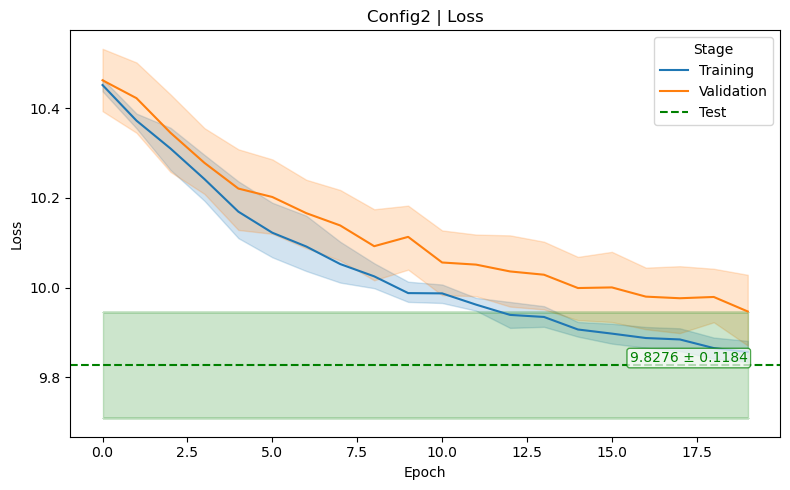

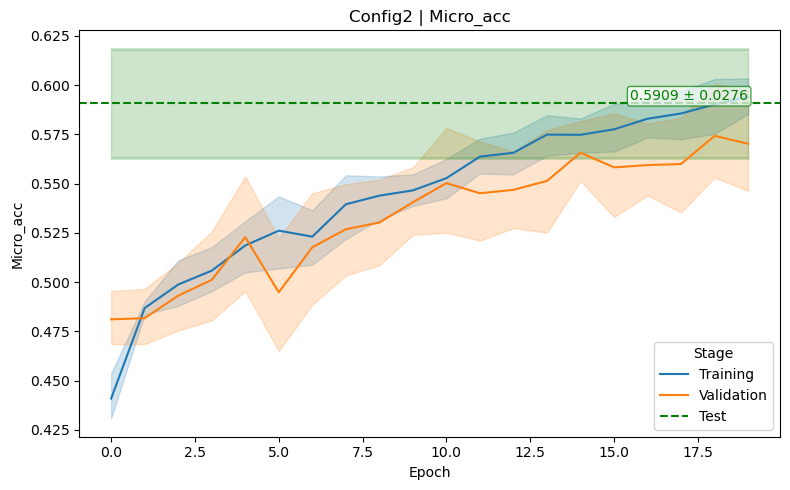

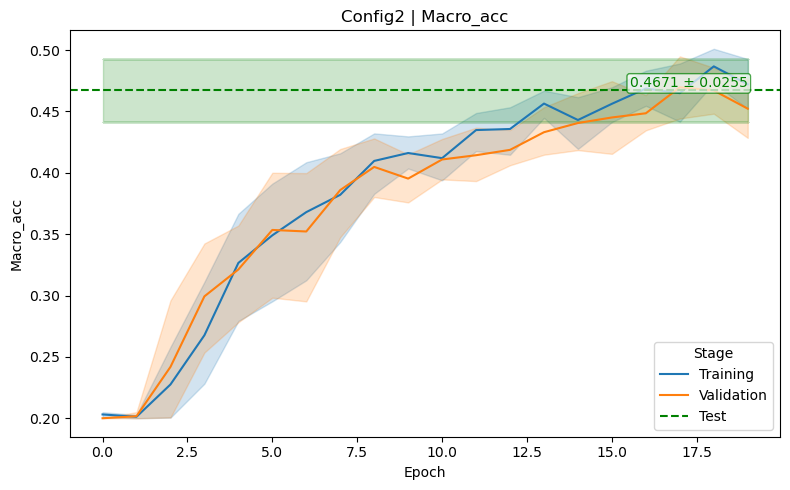

In [8]:
def dev_plot(dev_df:pd.DataFrame, summary_df:pd.DataFrame):
    figs = {}

    # for each config
    for config in dev_df['config'].unique():

        figs[config] = {}
        
        # df filtered for config
        df_config = dev_df[dev_df['config']==config]

        # for each metric
        for metric in df_config['metric'].unique():
            # filter and copy df for metric
            df_metric = df_config[df_config['metric'] == metric].copy()

            # rename
            df_metric['stage'] = df_metric['stage'].replace({'train':'Training', 'val':'Validation'})

            # init figure
            plt.figure(figsize=(8, 5))

            # plot dev
            sns.lineplot(data=df_metric, x='epoch', y='value', hue='stage')

            # get test vals
            test = summary_df[(summary_df['config'] == config) & (summary_df['metric'] == metric)] # get test vals
            test_mean = test['mean'].values[0]
            test_std = test['std'].values[0]

            # plot test mean (line)
            plt.axhline(
                y=test_mean,
                color='green',
                linestyle='--',
                label='Test'
            )

            # plot test std (area)
            plt.fill_between(
                x = df_metric['epoch'],
                y1 = test_mean - test_std,
                y2 = test_mean + test_std,
                color='green',
                alpha=0.2,
            )

            # add test label
            plt.text(
                x = max(df_metric['epoch']),
                y = test_mean,
                s = f'{test_mean:.4f} ± {test_std:.4f}',
                va = 'bottom',
                ha = 'right',
                color = 'green',
                bbox = dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='green', alpha=0.7)
            )

            # formatting
            plt.title(f'{config.capitalize()} | {metric.capitalize()}')
            plt.xlabel('Epoch')
            plt.ylabel(metric.capitalize())
            plt.legend(title='Stage')
            plt.tight_layout()
            
            # # make config subfolder
            # subfolder = self.folder / f'{trainer}' / f'{config}'
            # subfolder.mkdir(parents=True, exist_ok=True)

            # # Save the plot object (the current figure)
            # fig = plt.gcf()
            # figs[trainer][config][metric] = fig
            # # fig.savefig(subfolder / f'{trainer}_{config}_{metric}.svg')
            # plt.close()

dev_plot(expt.dev_df, expt.summary)

___

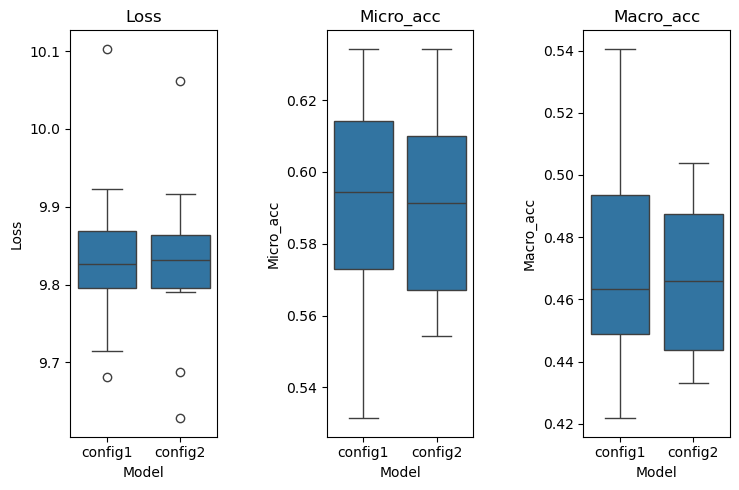

In [71]:
def test_plot(test_df):
    metrics = test_df['metric'].unique()
    n_metrics = len(metrics)

    fig, axes = plt.subplots(1, n_metrics, figsize=(2.5 * n_metrics, 5), sharey=False)

    if n_metrics == 1:
        axes = [axes]  # handle single-metric case

    for ax, metric in zip(axes, metrics):
        df_metric = test_df[test_df['metric'] == metric]
        sns.boxplot(data=df_metric, x='config', y='value', ax=ax)

        ax.set_title(metric.capitalize())
        ax.set_xlabel('Model')
        ax.set_ylabel(metric.capitalize())
        ax.tick_params(axis='x')

    plt.tight_layout()
    plt.close()
    fig.subplots_adjust(wspace=0.75)

    return fig

test_plot(expt.test_df)

In [ ]:
# post_init: loader x params -> trainer -> model

# save models -> viz.multi_model_output

# multi_model attention viz

# single viz:
    # pathway + genewise PCA/tSNE/UMAP
    # shape by pathway vs gene?
    # color by attention OR up/downregulation
    # opt: split by class?
    # opt: filter for specific genes or pathways; label gene+pathway